# GA Optimasi Posisi Object

GRID = 10 × 10

dan 5 objek: A,B,C,D,E

Aturan:
1. tidak boleh ada yang tumpang tindih

Setiap objek mempunyai posisi:
```
A = (x1, y1)
B = (x2, y2)
C = (x3, y3)
D = (x4, y4)
E = (x5, y5)
```


1. Masalah yang akan kita selesaikan

    Kita punya grid:
    ```
    10 × 10
    ```

    dan 5 objek:
    ```
    A
    B
    C
    D
    E
    ```

    Setiap objek mempunyai posisi:
    ```
    A = (x1, y1)
    B = (x2, y2)
    C = (x3, y3)
    D = (x4, y4)
    E = (x5, y5)
    ```

    Sehingga satu individual/chromosome menjadi:
    ```
    [
        (x1, y1),
        (x2, y2),
        (x3, y3),
        (x4, y4),
        (x5, y5)
    ]
    ```

    Contoh:
    ```

    [
        (1, 2),
        (8, 2),
        (4, 7),
        (2, 9),
        (8, 8)
    ]
    ```

2. Apa yang ingin dioptimalkan?

    Untuk versi pertama, kita gunakan total jarak antar semua objek.

    Misalnya:
    ```

    A ----- B
    C
    D ----- E
    ```

    Kita hitung:
    ```
    d(A,B)
    d(A,C)
    d(A,D)
    ```

    dan seterusnya.

    Kemudian:
    ```

    Fitness=
    i<j
    ∑d(i,j)
    ```

    Jadi semakin jauh objek satu sama lain, semakin tinggi fitness.

3. Kita gunakan Euclidean Distance
    ```
    Jarak dua titik:

    d=
    (x
    2
        ​

    −x
    1
        ​

    )
    2
    +(y
    2
        ​

    −y
    1
        ​

    )
    2
    ```

    Dalam Python:
    ```
    distance = math.sqrt(
        (x2 - x1) ** 2 +
        (y2 - y1) ** 2
    )
    ```

4. Chromosome

    Kita sekarang mempunyai struktur:
    ```
    Chromosome
    │
    ├── Object A → (x1, y1)
    ├── Object B → (x2, y2)
    ├── Object C → (x3, y3)
    ├── Object D → (x4, y4)
    └── Object E → (x5, y5)
    ```

    Jadi:
    ```
    [
        (1, 2),
        (8, 2),
        (4, 7),
        (2, 9),
        (8, 8)
    ]
    ```

    Ini berbeda dengan latihan sebelumnya.

    Sebelumnya:
    ```
    [x, y, z, a]
    ```

    Sekarang:
    ```

    [
        (x1, y1),
        (x2, y2),
        ...
    ]
    ```

    Ini adalah perubahan konsep yang penting.

In [3]:
import random
import math
import matplotlib.pyplot as plt

In [78]:
# =========================================
# 1. Parameter Genetic Algorithm
# =========================================

POPULATION_SIZE = 25
GENERATIONS = 150

GRID_SIZE = 10
NUMBER_OF_OBJECTS = 25

MUTATION_RATE = 0.1

MIN_DISTANCE = 1

In [82]:
# =========================================
# Fungsi Distance
# =========================================

def distance(point1, point2):

    x1, y1 = point1
    x2, y2 = point2

    return math.sqrt(
        (x2 - x1) ** 2 +
        (y2 - y1) ** 2
    )

# =========================================
# 2. Fungsi Fitness
# =========================================

def fitness(individual):
    total_distance = 0
    penalty = 0

    for i in range(NUMBER_OF_OBJECTS):

        for j in range(i + 1, NUMBER_OF_OBJECTS):

            d = distance(
                individual[i],
                individual[j]
            )
            
            total_distance += d
            # jika dua objek berada di posisi yang sama
            if d < MIN_DISTANCE:
                penalty += 1000

    return total_distance - penalty


# =========================================
# 3. Membuat individual
# =========================================

def create_individual():

    individual = []

    for _ in range(NUMBER_OF_OBJECTS):

        x = random.randint(0, GRID_SIZE - 1)
        y = random.randint(0, GRID_SIZE - 1)

        individual.append((x, y))

    return individual

In [6]:
# =========================================
# 5. Membuat population
# =========================================

def create_population():
    return [
        create_individual()
        for _ in range(POPULATION_SIZE)
    ]


# =========================================
# 6. Selection
# =========================================

def selection(population):
    population_sorted = sorted(
        population,
        key=fitness,
        reverse=True
    )

    # Ambil 50% terbaik
    return population_sorted[:POPULATION_SIZE // 2]


# =========================================
# 7. Crossover
# =========================================
def crossover(parent1, parent2):

    child1 = []
    child2 = []

    for i in range(NUMBER_OF_OBJECTS):

        if random.random() < 0.5:

            child1.append(parent1[i])
            child2.append(parent2[i])

        else:

            child1.append(parent2[i])
            child2.append(parent1[i])

    return child1, child2

# =========================================
# 8. Mutation
# =========================================
def mutation(individual):

    for i in range(NUMBER_OF_OBJECTS):

        if random.random() < MUTATION_RATE:

            x = random.randint(
                0,
                GRID_SIZE - 1
            )

            y = random.randint(
                0,
                GRID_SIZE - 1
            )

            individual[i] = (x, y)

    return individual




Generation 01 | Fitness = 1620.43 | Position = [(8, 6), (2, 2), (5, 0), (5, 8), (7, 4), (9, 0), (2, 4), (0, 6), (0, 5), (6, 2), (6, 8), (9, 3), (5, 7), (6, 6), (3, 0), (8, 2), (0, 3), (2, 9), (3, 2), (2, 8), (2, 6), (8, 4), (0, 7), (7, 9), (5, 1)]
Generation 02 | Fitness = 1690.57 | Position = [(2, 7), (8, 8), (4, 2), (8, 2), (8, 7), (7, 3), (5, 9), (3, 2), (5, 8), (0, 1), (6, 3), (9, 7), (7, 8), (1, 5), (8, 9), (7, 0), (8, 4), (1, 3), (6, 9), (8, 6), (9, 9), (0, 0), (7, 7), (0, 2), (9, 1)]
Generation 03 | Fitness = 1690.57 | Position = [(2, 7), (8, 8), (4, 2), (8, 2), (8, 7), (7, 3), (5, 9), (3, 2), (5, 8), (0, 1), (6, 3), (9, 7), (7, 8), (1, 5), (8, 9), (7, 0), (8, 4), (1, 3), (6, 9), (8, 6), (9, 9), (0, 0), (7, 7), (0, 2), (9, 1)]
Generation 04 | Fitness = 1690.57 | Position = [(2, 7), (8, 8), (4, 2), (8, 2), (8, 7), (7, 3), (5, 9), (3, 2), (5, 8), (0, 1), (6, 3), (9, 7), (7, 8), (1, 5), (8, 9), (7, 0), (8, 4), (1, 3), (6, 9), (8, 6), (9, 9), (0, 0), (7, 7), (0, 2), (9, 1)]
Generati

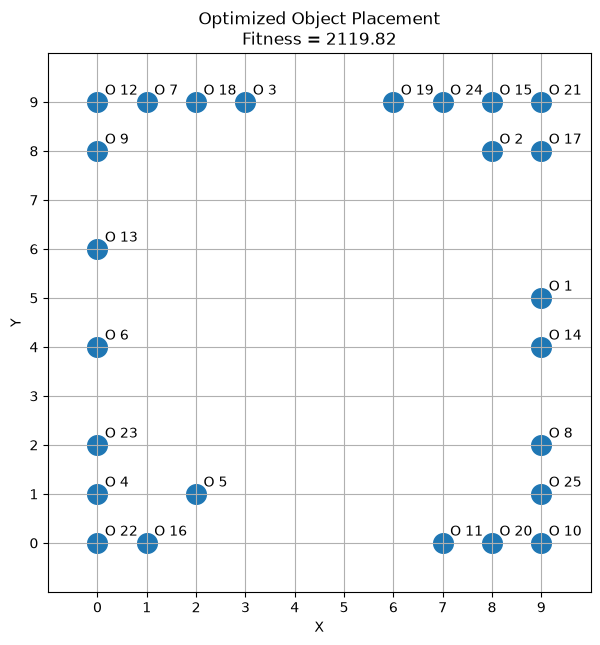

In [ ]:
# =========================================
# 9. Genetic Algorithm
# =========================================

population = create_population()


for generation in range(GENERATIONS):

    # -----------------------------
    # Evaluasi
    # -----------------------------

    best = max(
        population,
        key=fitness
    )

    # print(
    #     f"Generation {generation + 1:02d} | "
    #     f"Fitness = {fitness(best):.2f} | "
    #     f"Position = {best}"
    # )


    # -----------------------------
    # Selection
    # -----------------------------

    parents = selection(population)


    # -----------------------------
    # Membuat population baru
    # -----------------------------

    new_population = parents.copy()


    while len(new_population) < POPULATION_SIZE:

        parent1, parent2 = random.sample(parents, 2)

        child1, child2 = crossover(
            parent1,
            parent2
        )

        child1 = mutation(child1)
        child2 = mutation(child2)

        new_population.append(child1)

        if len(new_population) < POPULATION_SIZE:
            new_population.append(child2)


    population = new_population


# =========================================
# 10. Hasil akhir
# =========================================

best = max(
    population,
    key=fitness
)

print("\nHasil Akhir")

print("Position :", best)
print("Fitness  :", fitness(best))

# =========================================
# 11. Visualisasi
# =========================================

x = []
y = []

for point in best:

    x.append(point[0])
    y.append(point[1])


plt.figure(figsize=(7, 7))

plt.scatter(
    x,
    y,
    s=200
)

for i, point in enumerate(best):

    plt.text(
        point[0] + 0.15,
        point[1] + 0.15,
        f"O {i + 1}"
    )


plt.xlim(-1, GRID_SIZE)
plt.ylim(-1, GRID_SIZE)

plt.xticks(range(GRID_SIZE))
plt.yticks(range(GRID_SIZE))

plt.grid(True)

plt.xlabel("X")
plt.ylabel("Y")

plt.title(
    f"Optimized Object Placement\n"
    f"Fitness = {fitness(best):.2f}"
)

plt.show()